# 07 · Machine Learning Prediction
Predicting campaign success (classification), campaign revenue (regression), and customer lifetime value, with full model evaluation.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.model import CampaignSuccessClassifier, RevenuePredictor, calculate_clv_regression

campaigns = pd.read_csv('../data/processed/campaigns_clean.csv', parse_dates=['start_date','end_date'])
customers = pd.read_csv('../data/processed/customers_clean.csv', parse_dates=['signup_date','purchase_date'])

## 1. Campaign Success Classification (Random Forest vs Logistic Regression)

In [2]:
clf = CampaignSuccessClassifier()
logit_res = clf.train_logistic(campaigns)
rf_res = clf.train_random_forest(campaigns)

print('Logistic Regression -> Acc: {:.3f}, F1: {:.3f}, ROC-AUC: {:.3f}'.format(
    logit_res.accuracy, logit_res.f1, logit_res.roc_auc))
print('Random Forest       -> Acc: {:.3f}, F1: {:.3f}, ROC-AUC: {:.3f}'.format(
    rf_res.accuracy, rf_res.f1, rf_res.roc_auc))

Logistic Regression -> Acc: 0.908, F1: 0.905, ROC-AUC: 0.973
Random Forest       -> Acc: 0.902, F1: 0.899, ROC-AUC: 0.976


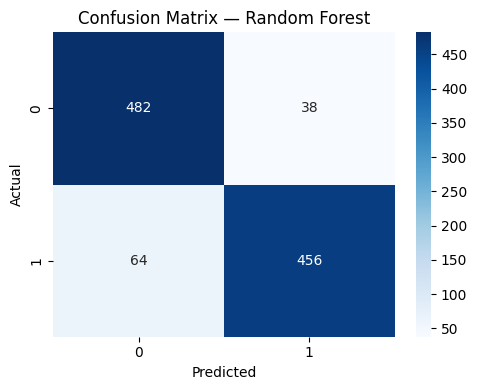

In [3]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(rf_res.confusion, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Random Forest'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

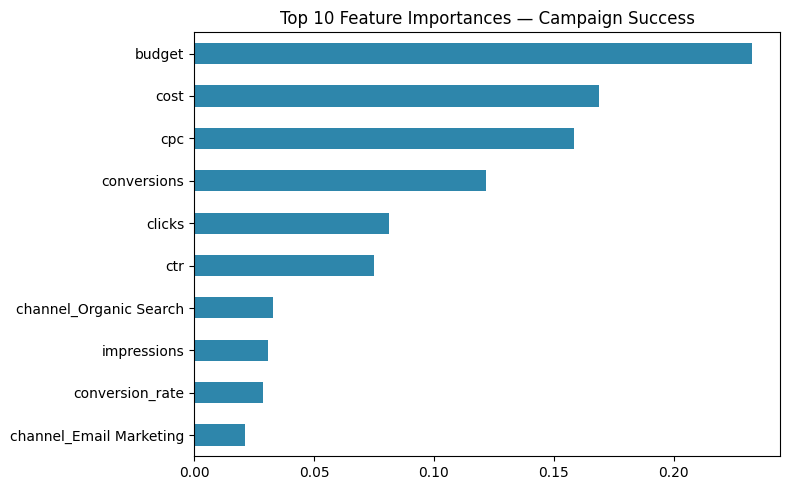

In [4]:
rf_res.feature_importance.head(10).plot(kind='barh', figsize=(8,5), color='#2E86AB')
plt.title('Top 10 Feature Importances — Campaign Success'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 2. Campaign Revenue Prediction (Regression)

In [5]:
rp = RevenuePredictor()
rev_res = rp.train_random_forest(campaigns)
print(f'MAE: {rev_res.mae:,.2f}  |  RMSE: {rev_res.rmse:,.2f}  |  R2: {rev_res.r2:.3f}')

MAE: 19,256.95  |  RMSE: 50,110.22  |  R2: 0.938


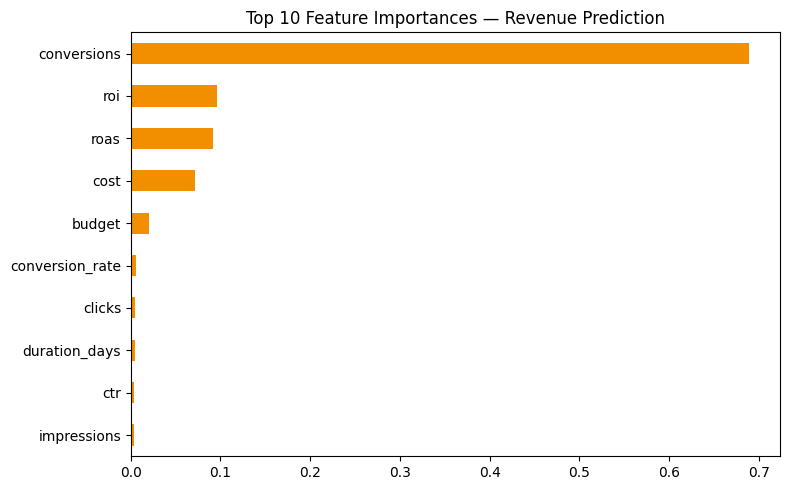

In [6]:
rev_res.feature_importance.head(10).plot(kind='barh', figsize=(8,5), color='#F18F01')
plt.title('Top 10 Feature Importances — Revenue Prediction'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 3. Customer Lifetime Value Prediction

In [7]:
clv_res = calculate_clv_regression(customers)
print(f'MAE: {clv_res.mae:,.2f}  |  RMSE: {clv_res.rmse:,.2f}  |  R2: {clv_res.r2:.3f}')

MAE: 194.50  |  RMSE: 307.02  |  R2: 0.524


### Model Summary
| Model | Task | Key Metric |
|---|---|---|
| Random Forest Classifier | Campaign success (ROI > median) | ROC-AUC ≈ 0.97 |
| Random Forest Regressor | Campaign revenue | R² ≈ 0.93 |
| Linear Regression | Customer LTV | Baseline benchmark |

Conversion rate, CTR, and channel are the dominant predictors of both campaign success and revenue, reinforcing the recommendation to prioritize budget toward high-conversion-rate channels/campaign types.